# Over-smoothing: when more neighbors erase distinctions

Start with retrieval. Three live TODOs feed full, visible experiments. The named paper figure is untrained: training it would change the experiment. The default Cora extension runs one seed per depth; set RUN_FULL_CORA=True for the complete ten-seed author protocol.

In [1]:
# @colab-bootstrap
import sys,subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','numpy==2.5.0','scipy==1.18.0','torch==2.13.0','matplotlib==3.11.0'])

<p class="eyebrow">Depth is a trade-off · distinguish mixing from optimization</p>



## Your win

Diagnose whether repeated graph propagation is erasing distinctions between nodes. You will derive a three-node limit, reproduce the full setup of Li, Han and Wu’s karate-club visualization, and compare trained GCN accuracy with representation similarity as depth increases. This matters for the mission: a larger relational neighborhood is useful only if the model can preserve the distinctions needed for prediction.

Start with the 25-minute explanation. The notebook is a separate implementation session. The short karate experiment and the longer Cora diagnostic have separate commands and evidence.



## Retrieve before reading

Without opening earlier lessons, write down the GCN propagation rule, explain what a GAT attention coefficient normalizes over, and name the labels allowed to influence stopping.

Write your prediction or explanation before continuing. Use the lesson page for the interactive control.

<details><summary>Check your recall</summary><p>A GCN layer computes H′ = σ(SHW), with S determined by the graph and augmented degrees. GAT normalizes scores over one receiver’s allowed senders within one head. Validation labels may control stopping; test labels score the frozen result. See <a href="https://avistian.github.io/relational/lessons/0082-gcn.html">L082</a> and <a href="https://avistian.github.io/relational/lessons/0084-gat.html">L084</a>.</p></details>



## Why another layer can remove information

In L084, attention let a node weight its neighbors differently. Depth asks a separate question: what happens when we repeatedly mix already-mixed representations? Attention does not, by itself, guarantee that distinctions survive arbitrary depth. This lesson analyzes a **fixed GCN propagation matrix**. It does not prove a limit for every feature-dependent attention network.

**In plain terms.** Mixing helps when nearby nodes carry complementary evidence about the same class. Repeated mixing can also blur evidence across class boundaries. A larger receptive field—the set of nodes that can affect a prediction—therefore has a cost.

**Over-smoothing** means node representations lose discriminative differences through repeated graph mixing. A representation is the vector of numbers carried by a node. A connected component is a group of nodes linked by paths, with no path to the rest of the graph. Mixing cannot cross components with no connecting edge. [Primary reading: Li et al., §3, “When GCNs Fail”](https://arxiv.org/abs/1801.07606).



## Work one propagation step

**Worked example.** Take the undirected path A—B—C, initial scalar features `[2,4,8]`, and add one self-loop at every node. The augmented degrees are `[2,3,2]`. Here “degree” counts neighboring edges plus the added self-loop.

Ordinary neighborhood averaging uses `P = D̃⁻¹(A+I)`. Its first output is `[3,14/3,6]`, approximately `[3,4.667,6]`. The first node averages 2 and 4; the middle averages all three values. Every row of P sums to one.

GCN uses symmetric normalization, `S = D̃⁻¹/²(A+I)D̃⁻¹/²`. An edge from j to i gets weight `1/√(d̃_i d̃_j)`. Its first output is approximately `[2.633,5.416,5.633]`. For B, the calculation is `2/√6 + 4/3 + 8/√6`. These rows need not sum to one. `I` is the identity matrix and `D̃` is the diagonal matrix containing the augmented degrees.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">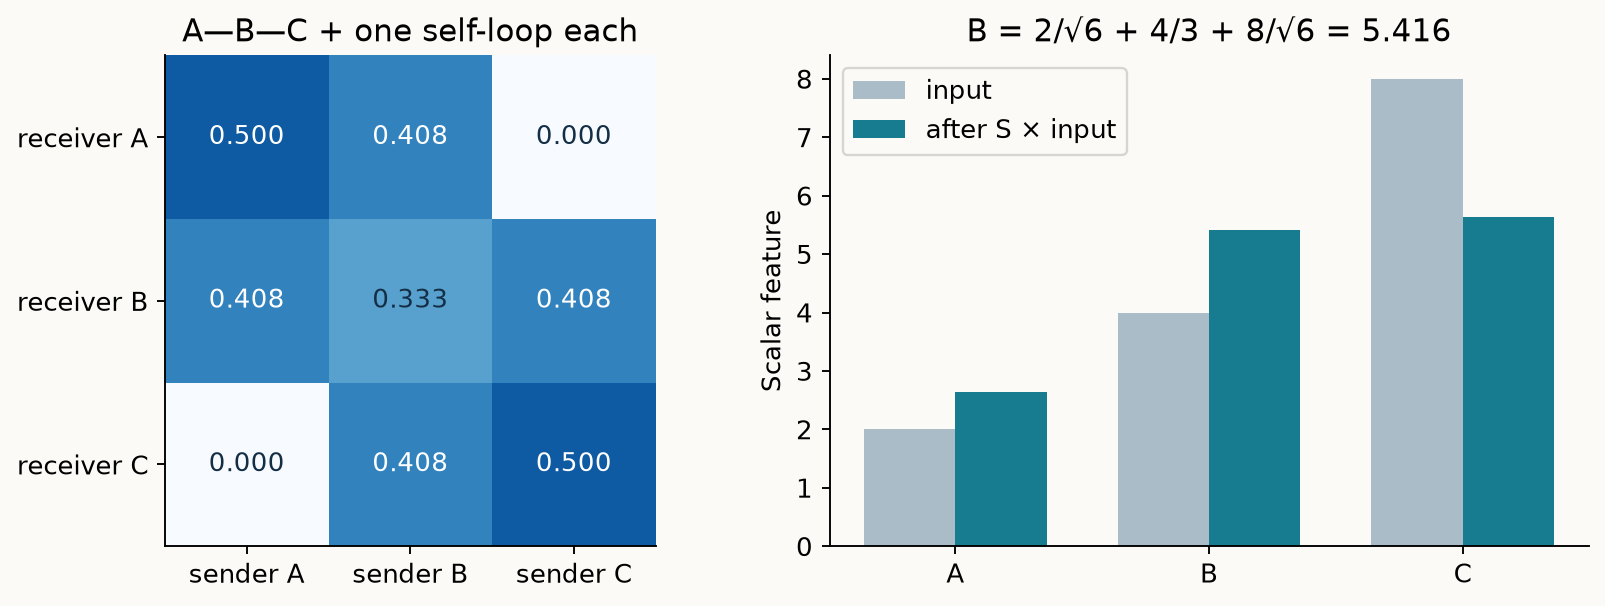</div><figcaption>A three-node arithmetic trace: receiver B combines sender values with symmetric degree weights.</figcaption></figure>

**Predict first:** after 100 steps, will raw GCN features be identical? Will removing B—C prevent A and C from mixing? Change the controls only after committing an answer. The widget holds features fixed and recomputes from depth zero for each intervention.

Write your prediction or explanation before continuing. Use the lesson page for the interactive control.



## Derive the limit instead of memorizing “collapse”

**In plain terms.** Repeated propagation preserves one special direction in each connected component. Other directions shrink. For symmetric normalization, the preserved direction grows with the square root of degree.

**Find the preserved direction.** Write `q_i = √d̃_i / √Σ_j d̃_j` on this connected graph. Multiplying gives `S q = q`: the right degree factor cancels the square root in q, summing a row of `A+I` gives d̃_i, and the left factor leaves √d̃_i. Thus q is a unit-length eigenvector with eigenvalue 1. An eigenvector is a direction that multiplication only rescales; its eigenvalue is that scale.

**Repeat the multiplication.** Since S is symmetric, it has orthogonal eigenvectors. Expand a feature column in those directions. Applying S k times multiplies each coefficient by `λ^k`, where λ is that direction’s eigenvalue. On a finite connected undirected graph with positive self-loops, every other eigenvalue has absolute value less than 1. Those terms vanish as k grows. Therefore `S^k X → q(qᵀX)`.

**Check the numbers.** For our path, the limit is approximately `[4.257,5.213,4.257]`. Raw values differ because B has larger degree. Dividing each row by `√d̃_i` produces the same value, approximately 3.010. Ordinary averaging instead converges to a degree-weighted mean, `(2×2 + 3×4 + 2×8)/7 = 32/7`, at every node.

**Several components.** There is one preserved direction per component. A global variance can remain positive even after complete mixing within every component. Do not mistake separated components for a failed theorem.

**Low-pass intuition.** A graph frequency describes how much a direction varies across linked nodes. Slowly varying directions survive longer. Repeated propagation suppresses many rapidly varying directions; negative eigenvalues can cause alternating intermediate signs. “Low-pass” is an intuition about this filtering, not a claim that every raw statistic decreases at every step.

> **Scope check.** This limit is for repeated fixed linear propagation. A trained GCN also changes channel weights and applies nonlinearities. The theorem motivates a diagnostic; it does not prove every deep model fails. The paper’s prose describes square-root-degree scaling; the executable `S√d̃ = √d̃` check is the authority for our normalization convention.



## Measure collapse without confusing it with shrinking

Implement three live notebook functions: `smooth`, `collapse_metrics`, and `graph_layer`. The complete model, data loader and Cora trainer are provided inline. Your functions feed the experiments.

```python
corrected = h / degrees.sqrt()[:, None]
degree_variance = (corrected - corrected.mean(0)).square().mean()
norm = h.norm(dim=1)
u = h[norm > 0] / norm[norm > 0, None]
mean_cosine = (u.sum(0).square().sum() - len(u)) / (len(u)*(len(u)-1))
```

**Degree-corrected variance** measures spread after dividing out the known degree factor. It approaches zero for our connected fixed propagation example. It is scale-sensitive: multiplying every feature by 0.001 also reduces it by a million, without making directions more alike.

**Mean off-diagonal cosine similarity** compares directions of distinct nonzero node vectors. A cosine of 1 means matching directions, 0 means perpendicular directions, and −1 means opposite directions. Normalization removes magnitude. The sum formula avoids constructing all node pairs. Zero vectors have no direction; the implementation excludes them and reports their count. Fewer than two nonzero rows makes the statistic undefined, represented by `None`.

**Use both.** Also inspect feature RMS, the square root of the average squared coordinate, and training accuracy. If accuracy drops while similarity stays modest, optimization or a poor representation may be involved. If variance drops only because RMS shrinks, you have not established directional collapse. There is no universal similarity threshold for task failure.



## Reproduce the paper’s actual figure

**Named target: Li et al. Figure 2.** All 34 karate-club nodes, 78 undirected binary edges, identity features of shape `[34,34]`, GCN depths 1–5, hidden width 16, output width 2, and Glorot random initialization. Glorot uniform draws each weight from a symmetric interval with bound `√(6/(fan_in+fan_out))`. The networks are **untrained**. Class labels color the output points; they never enter the forward pass. There is no optimizer, objective, training split, checkpoint selection, or accuracy target in this experiment. [Paper §3](https://arxiv.org/abs/1801.07606).

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">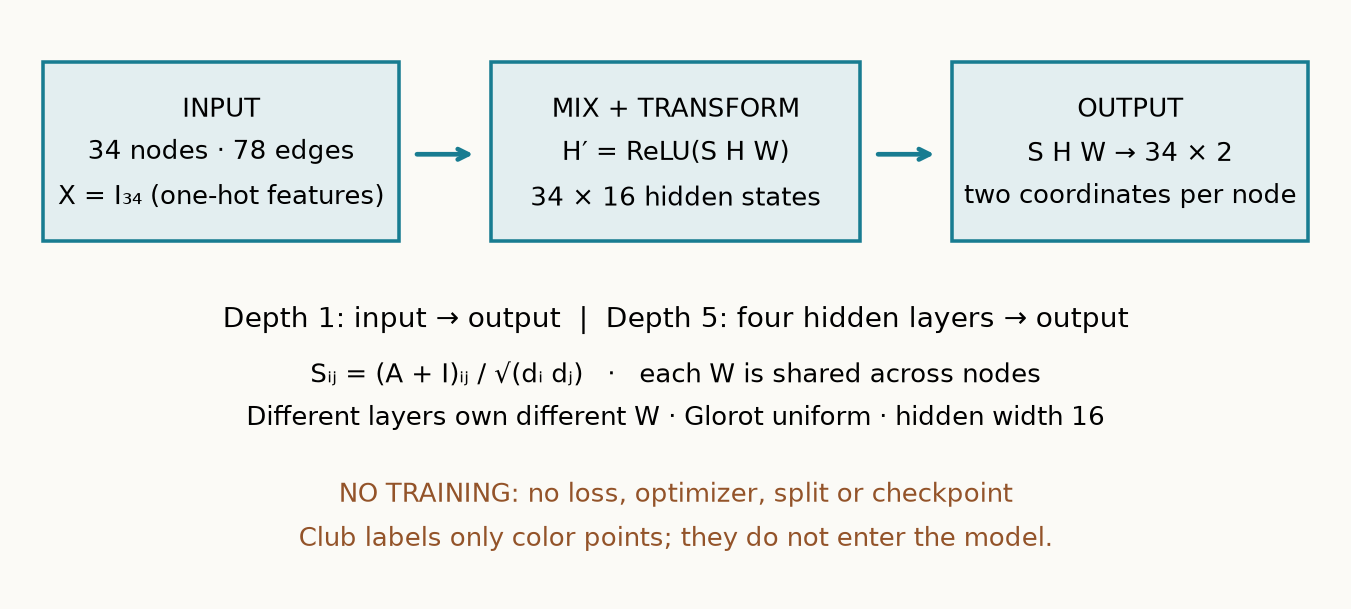</div><figcaption>Full Figure 2 setup: identity features, repeated GCN layers, two untrained output coordinates, labels only for plotting.</figcaption></figure>

Hidden layers apply `ReLU(SHW)`, where ReLU replaces negative values with zero. The final layer returns two linear coordinates. Parameters are shared across nodes within a layer, but layers own different weights. Depth 1 maps 34 inputs directly to 2 outputs. Depth 5 uses four 16-coordinate hidden layers and a final 2-coordinate output. Evaluation mode disables dropout. These conventions follow the [pinned released model](https://github.com/liqimai/gcn/blob/3b30a2d35ca2b144bf0f36337f233d407a7e2dd6/gcn/models.py).

**Predict before revealing:** should every random seed show its clearest separation at depth 2? A single illustration cannot answer that stability question.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">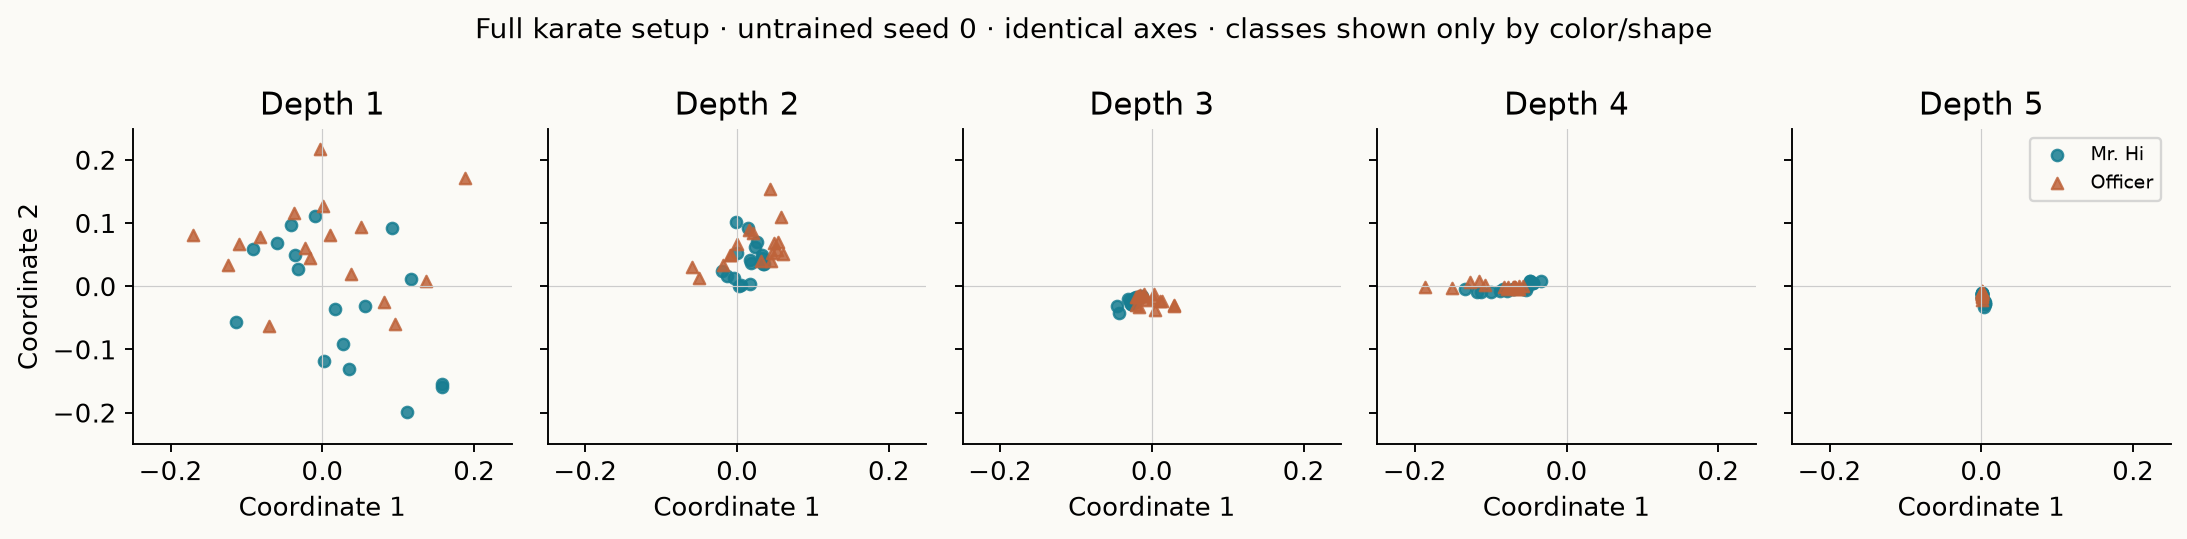</div><figcaption>Seed 0, chosen in advance; all five depths on the complete karate graph, with identical axes.</figcaption></figure>

**Author experiment.** All five depths ran for 100 declared seeds: 500 full-graph forward experiments. Seed 0 is displayed without visual selection; all coordinates are saved. Identical axis limits make shrinking visible. Because random output coordinates can rotate and change sign between networks, compare class mixing within a panel, not the identity of a coordinate across depths. The notebook lets you inspect other seeds.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">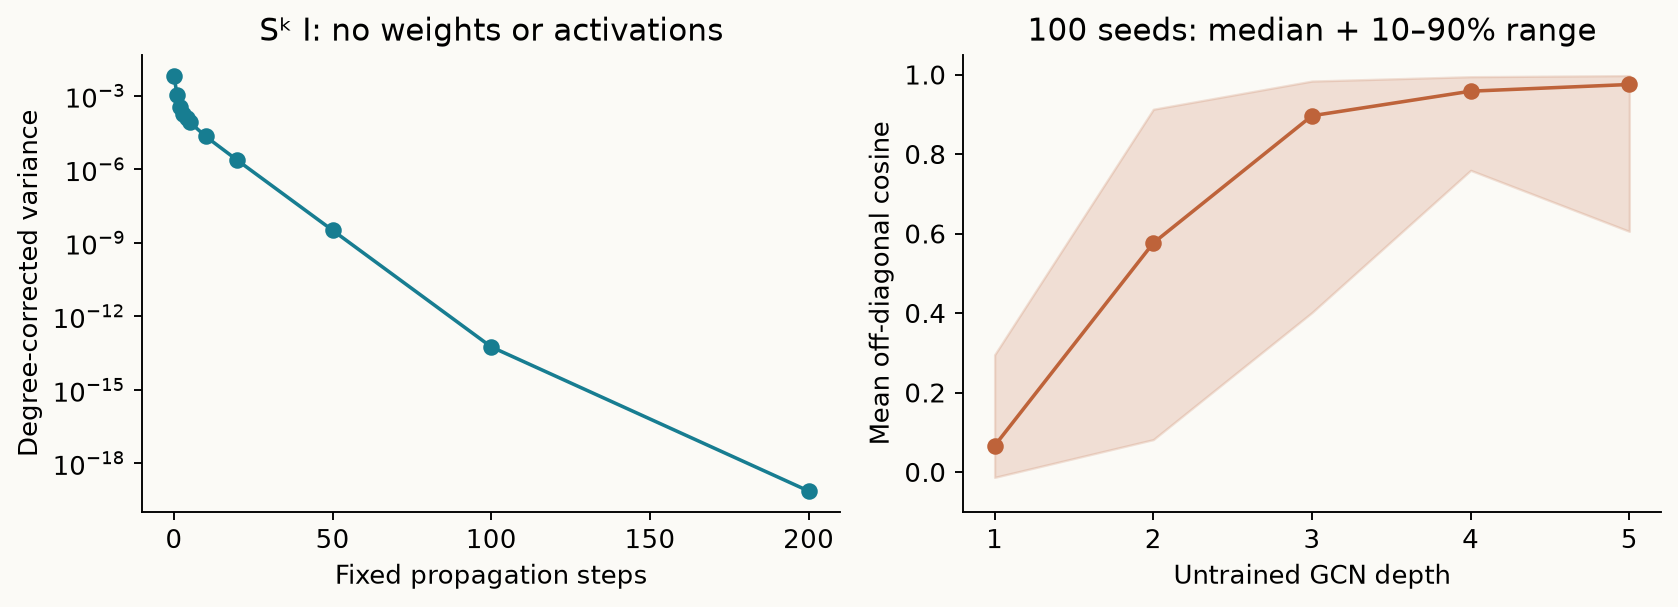</div><figcaption>Fixed linear propagation and random nonlinear networks are separate experiments. Shading reports initialization variation.</figcaption></figure>

The separate fixed-propagation curve removes random weights and activations. It isolates the linear mechanism tested by the theorem. The random-network curve reports the median and 10th–90th percentiles over seeds; it measures initialization variability, not uncertainty over independent graphs. A small variance alone is not a reproduction of the paper’s visual class-mixing claim.

> **Scope check.** Full setup reconstruction is executed. Exact historical figure parity is **INCOMPARABLE**: the inspected release does not supply the Figure 2 seed, weights, or plotting driver. Hidden ReLU and linear output use its GCN conventions. No seed is chosen to imitate the published picture. The paper’s co-training and self-training benchmark tables are separate and **NOT_RUN**. See the [protocol audit](https://avistian.github.io/relational/labs/l085-reproduction.md).



## Does a trained model lose accuracy too?

**Held fixed.** Full Cora graph, the L082 fixed label split, row-normalized features, hidden width 16, Adam learning rate 0.01, dropout 0.5, and the same validation stopping rule. Only depth varies across `[1,2,4,8,16]`. Ten initialization seeds are declared per depth. Both nodes and edges of the transductive graph are visible during training, but only training labels enter the loss.

**Measured.** Test accuracy after stopping, training accuracy, and the last hidden representation’s similarity, variance and RMS. Depth 1 has no hidden layer, so its diagnostic uses output logits and is marked separately. The optimizer gets at most 200 epochs; the loss includes L082’s first-weight L2 penalty. The parameter count changes with depth, so this is a practical depth diagnostic rather than a pure intervention on mixing alone.

**Fresh author results, separate from your kernel:**

| Depth | Test accuracy, mean ± sample SD | Mean cosine |
|---|---|---|
| 1 | 71.57% ± 0.69 pp | 0.221 |
| 2 | 81.40% ± 0.64 pp | 0.643 |
| 4 | 70.52% ± 6.17 pp | 0.603 |
| 8 | 15.60% ± 4.04 pp | 0.789 |
| 16 | 12.24% ± 4.06 pp | 1.000 |

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">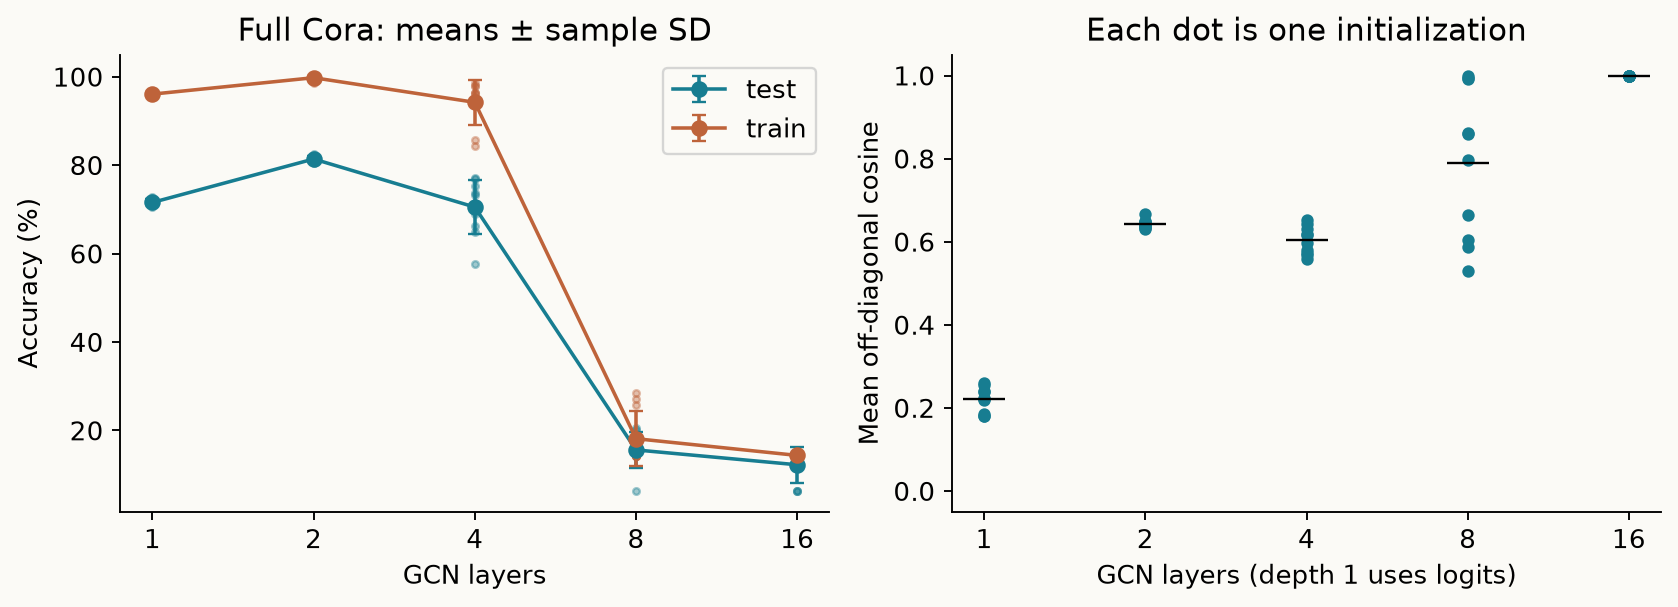</div><figcaption>Cora extension: all ten seeds at each depth; error bars are sample SD on one fixed split, not dataset uncertainty.</figcaption></figure>

**Read these measurements carefully.** The four-layer model has lower average cosine than the two-layer model, despite worse accuracy. The sixteen-layer model has cosine approximately 1 and poor training accuracy as well as poor test accuracy. The first observation refutes a simple rule that every extra trained layer must increase this statistic. The second is consistent with severe representation collapse, while the optimization failure still needs attention. Preserve both observations in your diagnosis.

**Interpret the combination.** Use training accuracy to detect failure even on supervised nodes. Use cosine together with the count of nonzero rows and RMS to inspect representation loss. Test scores describe this fixed graph and split. Do not select a deployment depth using the test curve; that would require a separate validation-only choice and untouched evaluation.

> **Scope check.** This is a locally specified extension of the L082 GCN experiment. It is not Li et al.’s Figure 2 or their random-split classification tables. Seeds are repetitions on one graph, not independent datasets. A falling curve supports a failure diagnosis for this setup, not a universal depth limit.



## Remedies are hypotheses to test

**Residual paths** add an earlier representation to a later one, creating a route that bypasses some transformations. They can improve optimization and retention. A simple lazy average `(1−α)I+αS` still has the same eventual fixed subspace for `0<α≤1`; slowing mixing is not eliminating its limit.

**Retaining original features** gives a predictor direct access to information that propagation may erase. **Changing edges or aggregation** changes the mixing operator and its trade-offs. Test a remedy with validation-only choices and matched compute. None of these names guarantees a gain.

**Over-squashing is different.** It describes too many distant signals being compressed through a limited communication path or fixed-width representation. Over-smoothing describes representations becoming insufficiently distinct. A model can exhibit either, both, or neither. This distinction will matter when relational graphs contain high-degree hubs and long dependency chains.



## Lab and exit artifact

Open the [student notebook](https://avistian.github.io/relational/labs/0085-over-smoothing.ipynb). Implement the three TODOs, pass the arithmetic and component checks, run the named karate experiment, then run or inspect the separately labeled Cora evidence. Full commands and pinned dependencies are in the [reproduction contract](https://avistian.github.io/relational/labs/l085-reproduction.md).

Submit your result JSON, depth-versus-accuracy and similarity curves, and a short diagnosis. Explain why equal raw features are the wrong symmetric-normalization target; show a disconnected counterexample; distinguish the untrained paper figure from trained accuracy evidence; and propose one validation-only remedy experiment. Change one operator deliberately and include the failing CHECK plus your repair.

Write your prediction or explanation before continuing. Use the lesson page for the interactive control.

Ask the agent follow-up questions and paste your diagnosis for strict feedback. Generating or executing this lesson does not mark it mastered. Keep the [reference card](https://avistian.github.io/relational/reference/over-smoothing.html) for spaced review. The next curriculum lesson introduces PyG: use these numerical contracts to check that a library pipeline computes the intended graph operations.


## PROVIDED · attribution

Operations follow liqimai/gcn revision 3b30a2d35ca2b144bf0f36337f233d407a7e2dd6. The separate Cora loader follows tkipf/gcn revision 39a4089fe72ad9f055ed6fdb9746abdcfebc4d81 (L082).

```text
The MIT License

Copyright (c) 2016 Thomas Kipf

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
THE SOFTWARE.
```

In [2]:
import json

In [3]:
import hashlib

In [4]:
from pathlib import Path

In [5]:
import numpy as np

In [6]:
import torch

In [7]:
from torch import nn

In [8]:
import torch.nn.functional as F

### PROVIDED · support

Binary, symmetric, loop-free adjacency -> dense symmetric support and augmented degrees.

In [9]:
def support(adjacency):
    """Binary, symmetric, loop-free adjacency -> dense symmetric support and augmented degrees."""
    a=torch.as_tensor(adjacency,dtype=torch.float64)
    if a.ndim!=2 or a.shape[0]!=a.shape[1] or not torch.equal(a,a.T):
        raise ValueError('Expected square undirected adjacency')
    if torch.any(a.diag()!=0) or torch.any((a!=0)&(a!=1)):
        raise ValueError('Use binary edges without self loops')
    augmented=a+torch.eye(len(a),dtype=a.dtype)
    d=augmented.sum(1)
    return augmented/d.sqrt()[:,None]/d.sqrt()[None,:],d

### TODO · smooth

TODO contract: return S^steps H without weights, activation, or in-place mutation.

In [10]:
def smooth(s,h,steps):
    """TODO contract: return S^steps H without weights, activation, or in-place mutation."""
    if not isinstance(steps,int) or steps<0:raise ValueError('steps must be a nonnegative integer')
    for _ in range(steps):h=s@h
    return h

In [11]:
s=torch.tensor([[.5,.5],[.5,.5]],dtype=torch.float64)
h=torch.tensor([[0.],[4.]],dtype=torch.float64)
torch.testing.assert_close(smooth(s,h,0),h)
torch.testing.assert_close(smooth(s,h,2),torch.tensor([[2.],[2.]],dtype=torch.float64))
assert h[0]==0, 'Do not mutate the input'
print('CHECK: simultaneous propagation and depth zero')

CHECK: simultaneous propagation and depth zero


### TODO · collapse_metrics

TODO contract: degree-corrected variance and mean off-diagonal cosine over nonzero rows.
Variance is mean squared deviation of H/sqrt(d) from its column means.
Cosine is undefined (None) when fewer than two rows are nonzero; report their count.

In [12]:
def collapse_metrics(h,degrees):
    """TODO contract: degree-corrected variance and mean off-diagonal cosine over nonzero rows.
    Variance is mean squared deviation of H/sqrt(d) from its column means.
    Cosine is undefined (None) when fewer than two rows are nonzero; report their count.
    """
    corrected=h/degrees.sqrt()[:,None]
    variance=float((corrected-corrected.mean(0)).square().mean())
    norms=h.norm(dim=1);nonzero=norms>0;u=h[nonzero]/norms[nonzero,None];n=len(u)
    cosine=float(((u.sum(0).square().sum()-n)/(n*(n-1))).clamp(-1,1)) if n>1 else None
    return {'degree_variance':variance,'mean_cosine':cosine,'nonzero_rows':n,'rms':float(h.square().mean().sqrt())}

In [13]:
h=torch.tensor([[1.,0.],[0.,1.]],dtype=torch.float64);d=torch.ones(2,dtype=torch.float64)
m=collapse_metrics(h,d)
assert abs(m['degree_variance']-.25)<1e-12
assert abs(m['mean_cosine'])<1e-12
assert collapse_metrics(torch.zeros_like(h),d)['mean_cosine'] is None
q=torch.tensor([2.,3.,2.],dtype=torch.float64).sqrt()
assert collapse_metrics(q[:,None],q.square())['degree_variance']<1e-20
print('CHECK: scale, degree correction, zero directions')

CHECK: scale, degree correction, zero directions


### TODO · graph_layer

TODO contract: [N,N] support, [N,F] states, [F,C] weights -> [N,C] states.

In [14]:
def graph_layer(s,h,w):
    """TODO contract: [N,N] support, [N,F] states, [F,C] weights -> [N,C] states."""
    return s@(h@w)

In [15]:
s=torch.tensor([[1.,0.],[.5,.5]])
h=torch.tensor([[2.,0.],[0.,4.]])
w=torch.tensor([[3.],[2.]])
torch.testing.assert_close(graph_layer(s,h,w),torch.tensor([[6.],[7.]]))
print('CHECK: receiver routing and channel transform')

CHECK: receiver routing and channel transform


### PROVIDED · DeepGCN

Glorot-uniform, bias-free GCN; width 16, hidden ReLU, linear final coordinates.
Figure 2 uses eval mode, no optimization and two output coordinates.
The separate Cora extension applies dropout .5 before every layer while training.

In [16]:
class DeepGCN(nn.Module):
    """Glorot-uniform, bias-free GCN; width 16, hidden ReLU, linear final coordinates.
    Figure 2 uses eval mode, no optimization and two output coordinates.
    The separate Cora extension applies dropout .5 before every layer while training.
    """
    def __init__(self,features,outputs,depth,dropout=0.):
        super().__init__()
        if depth<1:raise ValueError('depth must be positive')
        dims=[features]+[16]*(depth-1)+[outputs]
        self.weights=nn.ParameterList([nn.Parameter(torch.empty(a,b)) for a,b in zip(dims,dims[1:])])
        for w in self.weights:nn.init.xavier_uniform_(w)
        self.dropout=dropout

    def forward(self,x,s,return_hidden=False):
        states=[]
        for i,w in enumerate(self.weights):
            x=graph_layer(s,F.dropout(x,self.dropout,training=self.training),w)
            if i<len(self.weights)-1:x=F.relu(x)
            states.append(x)
        return (x,states) if return_hidden else x

### PROVIDED · karate_experiment

Full Figure 2 setup; depths 1..5; all 34 nodes; no training, selection, or data split.
Labels only color points. Seeds 0..99 are local, never chosen by visual separation.

In [17]:
def karate_experiment(graph,seeds=100):
    """Full Figure 2 setup; depths 1..5; all 34 nodes; no training, selection, or data split.
    Labels only color points. Seeds 0..99 are local, never chosen by visual separation.
    """
    a=np.zeros((34,34))
    for i,j in graph['edges']:a[i,j]=a[j,i]=1
    s,d=support(a);s=s.float();d=d.float();x=torch.eye(34);runs=[]
    for seed in range(seeds):
        for depth in range(1,6):
            torch.manual_seed(seed*10+depth)
            model=DeepGCN(34,2,depth).eval()
            with torch.no_grad():h=model(x,s)
            runs.append({'seed':seed,'rng_seed':seed*10+depth,'depth':depth,'coordinates':h.tolist(),**collapse_metrics(h,d)})
    pure=[]
    for depth in [0,1,2,3,4,5,10,20,50,100,200]:
        pure.append({'depth':depth,**collapse_metrics(smooth(s.double(),x.double(),depth),d.double())})
    return {'experiment':'Li et al. 2018 Figure 2, full setup reconstruction','status':'EXECUTED_WITH_DISCLOSED_GAPS','runs':runs,'pure_propagation_extension':pure,'graph_sha256':hashlib.sha256(json.dumps(graph,sort_keys=True).encode()).hexdigest(),'historical_coordinate_parity':'INCOMPARABLE','gaps':['Historical random seeds and weights unavailable','Modern PyTorch random number generator','Hidden ReLU and linear output follow released GCN convention; Figure 2 plotting driver not identified','Binary edges; NetworkX interaction weights deliberately ignored'],'not_run':['Li et al. co-training/self-training classification tables','Original TensorFlow Figure 2 execution']}

### PROVIDED · train_depth

Separate extension: full fixed Cora split, width16, Adam .01, first-weight L2.
Stop on current validation loss > previous-ten mean, using final weights as L082.
No test access until optimization and stopping are finished.

In [18]:
def train_depth(data,depth,seed,max_epochs=200):
    """Separate extension: full fixed Cora split, width16, Adam .01, first-weight L2.
    Stop on current validation loss > previous-ten mean, using final weights as L082.
    No test access until optimization and stopping are finished.
    """
    torch.manual_seed(seed)
    x,s,y,train,valid,test=data;x=x.to_dense() if x.is_sparse else x
    model=DeepGCN(x.shape[1],int(y.max())+1,depth,.5)
    opt=torch.optim.Adam(model.parameters(),lr=.01,eps=1e-8)
    history=[]
    def objective(z,index):return F.cross_entropy(z[index],y[index])+.00025*model.weights[0].square().sum()
    for epoch in range(max_epochs):
        model.train();opt.zero_grad();objective(model(x,s),train).backward();opt.step()
        model.eval()
        with torch.no_grad():value=float(objective(model(x,s),valid))
        history.append(value)
        if epoch>10 and value>np.mean(history[-11:-1]):break
    with torch.no_grad():
        logits,states=model(x,s,True)
        # Diagonal S_ii=1/d_i because exactly one self-loop was added.
        degrees=1/s.to_dense().diag()
        representation=states[-2] if len(states)>1 else states[-1]
        diagnostics=collapse_metrics(representation,degrees)
        accuracy=float((logits[test].argmax(1)==y[test]).float().mean())
        train_accuracy=float((logits[train].argmax(1)==y[train]).float().mean())
    return {'depth':depth,'seed':seed,'epochs':epoch+1,'test_accuracy':accuracy,'train_accuracy':train_accuracy,'validation_loss':history,'representation':'last hidden ReLU, or output at depth1',**diagnostics}

## CHECK · the theorem and its boundary

Predict: should a disconnected graph converge to one global value?

In [19]:
a=np.array([[0,1,0],[1,0,1],[0,1,0]],float)
s,d=support(a);x=torch.tensor([[2.],[4.],[8.]],dtype=torch.float64)
q=d.sqrt();q=q/q.norm()
limit=q[:,None]*(q@x)[None,:]
torch.testing.assert_close(smooth(s,x,200),limit)
print('Limit:',limit.flatten().tolist())
a=np.array([[0,1,0,0],[1,0,0,0],[0,0,0,1],[0,0,1,0]],float)
s,d=support(a);x=torch.tensor([[0.],[0.],[2.],[2.]],dtype=torch.float64)
torch.testing.assert_close(smooth(s,x,100),x)
assert collapse_metrics(x,d)['degree_variance']>0
print('CHECK: global collapse fails across disconnected components')

Limit: [4.256851281590388, 5.21355677540454, 4.256851281590388]
CHECK: global collapse fails across disconnected components


## Full named Figure 2 setup · 100 declared seeds

The graph bytes and labels are embedded for offline use. Labels are used only by the scatter plot. All depths and seeds are saved; do not cherry-pick the picture.

In [20]:
graph={'nodes': 34, 'edges': [[0, 1], [0, 2], [0, 3], [0, 4], [0, 5], [0, 6], [0, 7], [0, 8], [0, 10], [0, 11], [0, 12], [0, 13], [0, 17], [0, 19], [0, 21], [0, 31], [1, 2], [1, 3], [1, 7], [1, 13], [1, 17], [1, 19], [1, 21], [1, 30], [2, 3], [2, 7], [2, 8], [2, 9], [2, 13], [2, 27], [2, 28], [2, 32], [3, 7], [3, 12], [3, 13], [4, 6], [4, 10], [5, 6], [5, 10], [5, 16], [6, 16], [8, 30], [8, 32], [8, 33], [9, 33], [13, 33], [14, 32], [14, 33], [15, 32], [15, 33], [18, 32], [18, 33], [19, 33], [20, 32], [20, 33], [22, 32], [22, 33], [23, 25], [23, 27], [23, 29], [23, 32], [23, 33], [24, 25], [24, 27], [24, 31], [25, 31], [26, 29], [26, 33], [27, 33], [28, 31], [28, 33], [29, 32], [29, 33], [30, 32], [30, 33], [31, 32], [31, 33], [32, 33]], 'labels': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'source': 'NetworkX 3.6.1 karate_club_graph; binary edges, weight attributes ignored'}
torch.set_num_threads(1)
assert len(graph['edges'])==78 and len(graph['labels'])==34
result=karate_experiment(graph,100)
assert len(result['runs'])==500
Path('l085-karate-inline.json').write_text(json.dumps(result,indent=2))
print(result['status'],result['historical_coordinate_parity'])

EXECUTED_WITH_DISCLOSED_GAPS INCOMPARABLE


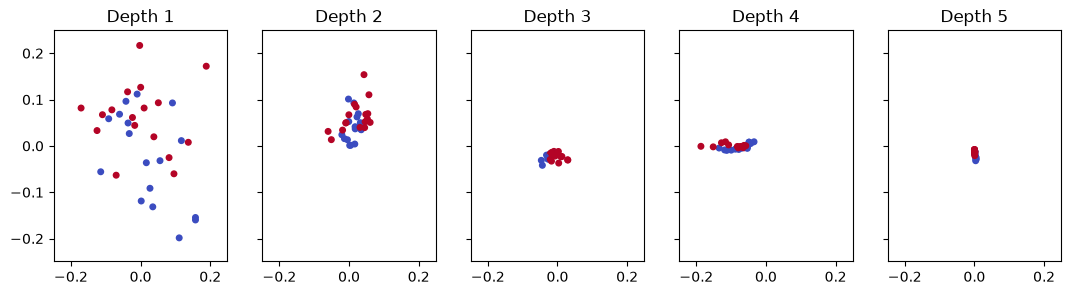

In [21]:
import matplotlib.pyplot as plt
VIEW_SEED=0 # decide before looking at the scatter
rows=[r for r in result['runs'] if r['seed']==VIEW_SEED]
fig,axes=plt.subplots(1,5,figsize=(13,3),sharex=True,sharey=True)
lim=max(abs(v) for r in rows for xy in r['coordinates'] for v in xy)*1.15
for ax,r in zip(axes,rows):
    z=np.array(r['coordinates']);ax.scatter(z[:,0],z[:,1],c=graph['labels'],cmap='coolwarm',s=16)
    ax.set(title=f"Depth {r['depth']}",xlim=(-lim,lim),ylim=(-lim,lim))
plt.show()

## PROVIDED · complete pinned Cora loader

Only known SHA-256-verified upstream files are deserialized. The manifest is embedded. The 140/500/1000 train/validation/test labels are disjoint. Features and graph structure are transductively visible.

In [22]:
from pathlib import Path

In [23]:
import hashlib

In [24]:
import json

In [25]:
import pickle

In [26]:
import urllib.request

In [27]:
import numpy as np

In [28]:
import scipy.sparse as sp

In [29]:
import torch

In [30]:
from torch import nn

In [31]:
import torch.nn.functional as F

### PROVIDED · as_sparse

Read the visible implementation.

In [32]:
def as_sparse(a):
    a=sp.coo_matrix(a)
    return torch.sparse_coo_tensor(np.array([a.row,a.col]),a.data.astype('float32'),a.shape).coalesce()

### PROVIDED · normalized_support

Binary undirected loop-free adjacency -> sparse D^-1/2 (A+I) D^-1/2.
Add exactly one self-loop per node BEFORE computing degrees; retain isolated nodes.

In [33]:
def normalized_support(a):
    """Binary undirected loop-free adjacency -> sparse D^-1/2 (A+I) D^-1/2.
    Add exactly one self-loop per node BEFORE computing degrees; retain isolated nodes.
    """
    a=sp.csr_matrix(a,dtype=float)
    if a.shape[0]!=a.shape[1] or (a-a.T).nnz or np.any(a.diagonal()):
        raise ValueError('Expected square undirected adjacency with no self-loops')
    if np.any(a.data!=1):raise ValueError('Expected binary adjacency')
    t=a+sp.eye(a.shape[0]);d=np.asarray(t.sum(1)).ravel()**-.5
    return as_sparse(sp.diags(d)@t@sp.diags(d))

### PROVIDED · load_cora

Verified pinned pickles only. Download missing files; reject changed bytes.

In [34]:
def load_cora(root=None):
    """Verified pinned pickles only. Download missing files; reject changed bytes."""
    if root is None:
        root=Path.cwd()
        if (root/'labs').is_dir():root=root/'labs'
        if not (root/'_sources_l078.json').exists():
            root=Path(__file__).resolve().parents[1]
    root=Path(root);manifest=json.loads((root/'_sources_l078.json').read_text())
    for record in manifest['files']:
        if not record['path'].startswith('data/'):continue
        p=root/record['path'];p.parent.mkdir(parents=True,exist_ok=True)
        if not p.exists():
            url='https://raw.githubusercontent.com/tkipf/gcn/'+manifest['revision']+'/'+record['upstream']
            p.write_bytes(urllib.request.urlopen(url,timeout=60).read())
        if hashlib.sha256(p.read_bytes()).hexdigest()!=record['sha256']:
            raise ValueError('Pinned data hash mismatch: '+str(p))
    folder=root/'data/l078'
    def read(name):
        with (folder/('ind.cora.'+name)).open('rb') as f:return pickle.load(f,encoding='latin1')
    x,y,tx,ty,allx,ally,graph=[read(k) for k in ['x','y','tx','ty','allx','ally','graph']]
    reorder=np.loadtxt(folder/'ind.cora.test.index',dtype=int);ordered=np.sort(reorder)
    features=sp.vstack((allx,tx)).tolil();features[reorder]=features[ordered]
    labels=np.vstack((ally,ty));labels[reorder]=labels[ordered]
    rows=[];cols=[]
    for i,neighbors in graph.items():
        for j in neighbors:rows.extend([i,j]);cols.extend([j,i])
    a=sp.coo_matrix((np.ones(len(rows)),(rows,cols)),shape=(len(labels),len(labels))).tocsr();a.data[:]=1
    s=normalized_support(a)
    mass=np.asarray(features.sum(1)).ravel();features=sp.diags(1/np.maximum(mass,1))@features
    return as_sparse(features),s,torch.tensor(labels.argmax(1)),torch.arange(len(y)),torch.arange(len(y),len(y)+500),torch.tensor(ordered)

In [35]:
cora_manifest={'revision': '39a4089fe72ad9f055ed6fdb9746abdcfebc4d81', 'repository': 'https://github.com/tkipf/gcn', 'files': [{'path': 'sources/l078/metrics.py', 'upstream': 'gcn/metrics.py', 'sha256': '953720296d440cfed948cd83c3162b72c4a5c759a5c1d1754254437cd0849f3f'}, {'path': 'sources/l078/utils.py', 'upstream': 'gcn/utils.py', 'sha256': '27bae983a6fdcaba352535e2a3edc46d1d9a0aabbcb7707c5212b41c27f9f8c4'}, {'path': 'sources/l078/models.py', 'upstream': 'gcn/models.py', 'sha256': 'd43548ab937264cf434e839dfd5768bd3e423579e48ae342608cafa4c8600c07'}, {'path': 'sources/l078/train.py', 'upstream': 'gcn/train.py', 'sha256': 'dab41c1c34315796ad998e1fcb4f8403719d059a970441ba358742a6bdd25136'}, {'path': 'sources/l078/LICENCE', 'upstream': 'LICENCE', 'sha256': 'f119df67ca11e39584fa0f5ee17cbfe8741b56b154d29fb21521e9ad01db57f8'}, {'path': 'sources/l078/layers.py', 'upstream': 'gcn/layers.py', 'sha256': 'c69ae03ae24aa6524eab61f2b2fec61c5938822fd225bdd4594406f1d24ec066'}, {'path': 'sources/l078/inits.py', 'upstream': 'gcn/inits.py', 'sha256': '21928770a797baf944392dee54eab83efaaa051a9d2365dee5d2f006689594a7'}, {'path': 'data/l078/ind.cora.ty', 'upstream': 'gcn/data/ind.cora.ty', 'sha256': '41f5ac76596a1699cc33f53084a2419e92961c42bb75f36fc38e616d348532ad'}, {'path': 'data/l078/ind.cora.ally', 'upstream': 'gcn/data/ind.cora.ally', 'sha256': '2b998f5cc7fedc86e7f97ca2498f47a1ffc1462c29e2d578b23bf3f62b6e7d71'}, {'path': 'data/l078/ind.cora.allx', 'upstream': 'gcn/data/ind.cora.allx', 'sha256': '9419ba2f26f5c35243db64aba110e0f35a04851609e0dc5433450676ca6b8543'}, {'path': 'data/l078/ind.cora.test.index', 'upstream': 'gcn/data/ind.cora.test.index', 'sha256': '297ce89af2b51a6a194181c7dbe1796c6a1cf9cd9349a88383b1b1e227867875'}, {'path': 'data/l078/ind.cora.x', 'upstream': 'gcn/data/ind.cora.x', 'sha256': '23cfa55d91c6f624233f5eb7b6e3f141f1bd2b2ae39608a63cf5d084bb27baab'}, {'path': 'data/l078/ind.cora.y', 'upstream': 'gcn/data/ind.cora.y', 'sha256': '94465c14eb53e04ca262198dcbb2521ee8af60fb3f3d546cd6ca24a511b0e7d1'}, {'path': 'data/l078/ind.cora.tx', 'upstream': 'gcn/data/ind.cora.tx', 'sha256': 'b9afbaa4a400df991f6f02ef677e1e44da55ffc04801fd02f9e673987829226a'}, {'path': 'data/l078/ind.cora.graph', 'upstream': 'gcn/data/ind.cora.graph', 'sha256': '58f13302f39dde8852dad6fe6d15b89b077b6d7f837626bce671ef80344b383d'}]}
DATA_ROOT=Path.cwd()/'l085-cora-data'
DATA_ROOT.mkdir(exist_ok=True)
p=DATA_ROOT/'_sources_l078.json'
if p.exists():assert json.loads(p.read_text())==cora_manifest, 'Existing provenance differs'
else:p.write_text(json.dumps(cora_manifest,indent=2))
data=load_cora(DATA_ROOT)
assert data[0].shape==(2708,1433)
assert [len(i) for i in data[3:]]==[140,500,1000]

/tmp/ipykernel_82014/4152342105.py:19: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  with (folder/('ind.cora.'+name)).open('rb') as f:return pickle.load(f,encoding='latin1')
/tmp/ipykernel_82014/2496567229.py:3: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:816.)
  return torch.sparse_coo_tensor(np.array([a.row,a.col]),a.data.astype('float32'),a.shape).coalesce()


## Extension · trained depth versus accuracy

This uses full data and the complete stopping schedule. One seed per depth is the default learning run; ten reproduce the author extension. This is not a published Li et al. table. The last hidden layer (output logits at depth1) supplies diagnostics.

In [36]:
RUN_FULL_CORA=False
seed_count=10 if RUN_FULL_CORA else 1
depth_runs=[]
for depth in [1,2,4,8,16]:
    for seed in range(seed_count):
        row=train_depth(data,depth,seed);depth_runs.append(row)
        print(depth,seed,row['test_accuracy'],row['mean_cosine'],row['rms'])
Path('l085-cora-inline.json').write_text(json.dumps({'experiment':'LOCAL_EXTENSION','runs':depth_runs},indent=2))

1 0 0.7120000123977661 0.238966703414917 0.12880319356918335


2 0 0.8040000200271606 0.6338025331497192 0.15646831691265106


4 0 0.7120000123977661 0.6524423956871033 0.7863370776176453


8 0 0.14399999380111694 0.8628959655761719 0.35566702485084534


16 0 0.14900000393390656 0.9997920989990234 1.086039083020296e-05


13761

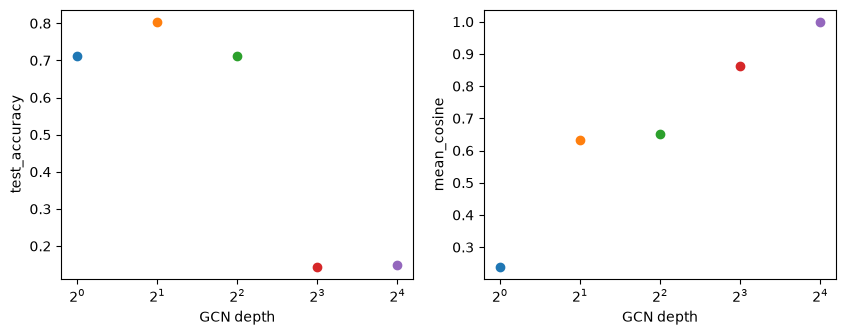

In [37]:
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
for ax,key in zip(axes,['test_accuracy','mean_cosine']):
    for depth in [1,2,4,8,16]:
        values=[r[key] for r in depth_runs if r['depth']==depth]
        ax.scatter([depth]*len(values),values)
    ax.set(xlabel='GCN depth',ylabel=key);ax.set_xscale('log',base=2)
plt.show()

## EXIT · learner-produced evidence

Attach both JSON files and your plots. Explain the degree-scaled limit, a disconnected counterexample, the role of RMS and zero rows, why the paper figure has no trainer, and which conclusion the Cora extension permits. Include one failing intervention and repair. Choose your definition of a practical collapse point before inspecting test scores; use validation evidence to propose a remedy. Ask the agent to assess your explanation.